<a href="https://colab.research.google.com/github/elikofi/MScProject/blob/main/Federated_Learning_Work_Elijah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRIVACY-PRESERVING FEDERATED LEARNING FOR INTRUSION DETECTION IN INTERNET OF HEALTHCARE THINGS: A DIFFERENTIAL PRIVACY–UTILITY TRADE-OFF ANALYSIS



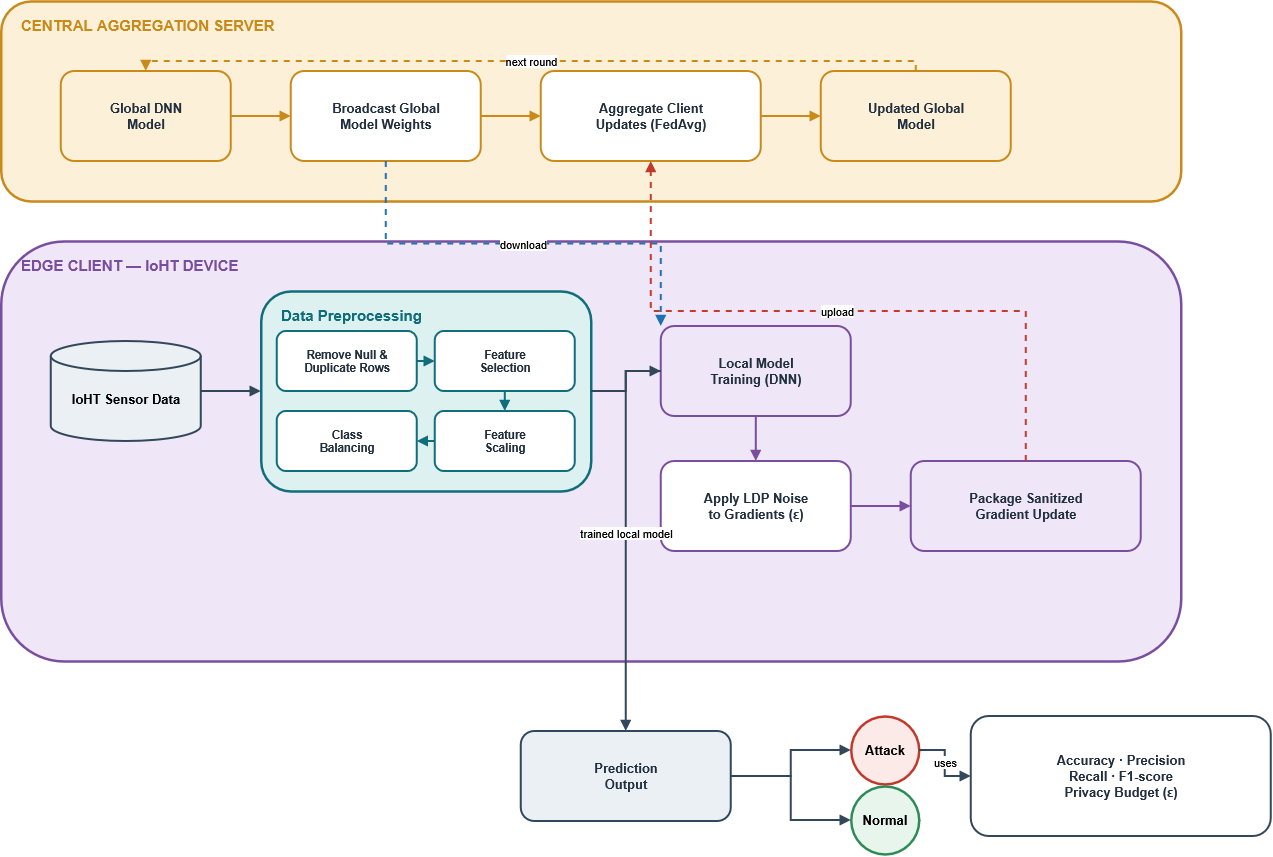

In [ ]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

import os
import sys
import time
import random
import copy
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

SEED = 42

# Federated-learning settings
NUM_CLIENTS = 2
BATCH_SIZE = 64
FEDERATED_ROUNDS = 100
LOCAL_EPOCHS = 1

# Optimisation
LEARNING_RATE = 0.01
MOMENTUM = 0.0

# Differential privacy
DELTA = 1e-4
MAX_GRAD_NORM = 1.0

# The supplied notebook used both 1.5 and 0.5.
DP_NOISE_LEVELS = [1.5, 0.5]

# Set True if you want the notebook to stop after a small smoke test.
# For the complete experiment requested, keep this False.
SMOKE_TEST = False
if SMOKE_TEST:
    FEDERATED_ROUNDS = 3

# Reproducibility
random.seed(SEED)
import numpy as np
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Federated rounds:", FEDERATED_ROUNDS)


Device: cuda
GPU: Tesla T4
Federated rounds: 100


In [ ]:
# ============================================================
# 2. INSTALL REQUIRED PACKAGES
# ============================================================

# Colab normally already contains torch, pandas, sklearn, numpy and matplotlib.
# Opacus is the additional package required for differential privacy.

!pip -q install opacus

import opacus
print("Opacus:", opacus.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 16.8 MB/s eta 0:00:00
Opacus: 1.6.0


In [ ]:
# ============================================================
# 3. MOUNT GOOGLE DRIVE AND AUTOMATICALLY FIND THE DATASET
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
DATASET_NAME = "WUSTL-EHMS-2020.csv"

matches = []
for root, dirs, files in os.walk(MYDRIVE):
    # Avoid common large/system folders when possible
    dirs[:] = [d for d in dirs if d not in {".Trash", ".cache", "__pycache__"}]
    if DATASET_NAME in files:
        matches.append(Path(root) / DATASET_NAME)

if not matches:
    raise FileNotFoundError(
        f"Could not find {DATASET_NAME} anywhere under {MYDRIVE}. "
        "Make sure the project folder is uploaded to Google Drive."
    )

print("Dataset candidates found:")
for i, p in enumerate(matches):
    print(f"[{i}] {p}")

CSV_FILE = matches[0]
PROJECT_DIR = CSV_FILE.parent
RESULTS_DIR = PROJECT_DIR / "colab_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("\nUsing dataset:")
print(CSV_FILE)
print("\nProject directory:")
print(PROJECT_DIR)
print("\nResults directory:")
print(RESULTS_DIR)


Mounted at /content/drive
Dataset candidates found:
[0] /content/drive/MyDrive/WUSTL-EHMS-2020.csv

Using dataset:
/content/drive/MyDrive/WUSTL-EHMS-2020.csv

Project directory:
/content/drive/MyDrive

Results directory:
/content/drive/MyDrive/colab_results


In [ ]:
# ============================================================
# 4. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from opacus import PrivacyEngine

print("All imports completed successfully.")


All imports completed successfully.


In [ ]:
# ============================================================
# 5. LOAD AND INSPECT THE RAW DATASET
# ============================================================

df_raw = pd.read_csv(CSV_FILE)

print("Dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df_raw.isnull().sum().sort_values(ascending=False).head(20).to_frame("missing"))

if "Label" not in df_raw.columns:
    raise ValueError("The dataset must contain a 'Label' column.")

print("\nClass distribution:")
display(df_raw["Label"].value_counts().sort_index().to_frame("count"))

print("\nFirst five rows:")
display(df_raw.head())


Dataset shape: (16318, 45)

Columns:
['Dir', 'Flgs', 'SrcAddr', 'DstAddr', 'Sport', 'Dport', 'SrcBytes', 'DstBytes', 'SrcLoad', 'DstLoad', 'SrcGap', 'DstGap', 'SIntPkt', 'DIntPkt', 'SIntPktAct', 'DIntPktAct', 'SrcJitter', 'DstJitter', 'sMaxPktSz', 'dMaxPktSz', 'sMinPktSz', 'dMinPktSz', 'Dur', 'Trans', 'TotPkts', 'TotBytes', 'Load', 'Loss', 'pLoss', 'pSrcLoss', 'pDstLoss', 'Rate', 'SrcMac', 'DstMac', 'Packet_num', 'Temp', 'SpO2', 'Pulse_Rate', 'SYS', 'DIA', 'Heart_rate', 'Resp_Rate', 'ST', 'Attack Category', 'Label']

Data types:


,dtype
Dir,object
Flgs,object
SrcAddr,object
DstAddr,object
Sport,object
Dport,int64
SrcBytes,int64
DstBytes,int64
SrcLoad,float64
DstLoad,float64



Missing values:


,missing
Dir,0
Flgs,0
SrcAddr,0
DstAddr,0
Sport,0
Dport,0
SrcBytes,0
DstBytes,0
SrcLoad,0
DstLoad,0



Class distribution:


,count
Label,
0,14272
1,2046



First five rows:


,Dir,Flgs,SrcAddr,DstAddr,Sport,Dport,SrcBytes,DstBytes,SrcLoad,DstLoad,...,Temp,SpO2,Pulse_Rate,SYS,DIA,Heart_rate,Resp_Rate,ST,Attack Category,Label
0,->,e,10.0.1.172,10.0.1.150,58059,1111,496,186,276914.0,92305.0,...,28.9,0,0,0,0,0,0,0.0,normal,0
1,->,e,10.0.1.172,10.0.1.150,58062,1111,496,186,230984.0,76995.0,...,28.9,0,0,0,0,78,17,0.4,normal,0
2,->,e,10.0.1.172,10.0.1.150,58065,1111,496,186,218470.0,72823.0,...,28.9,89,104,0,0,78,17,0.4,normal,0
3,->,e,10.0.1.172,10.0.1.150,58067,1111,496,186,203376.0,67792.0,...,28.9,89,104,0,0,79,17,0.4,normal,0
4,->,e,10.0.1.172,10.0.1.150,58069,1111,496,186,235723.0,78574.0,...,28.9,89,101,0,0,79,17,0.4,normal,0


## Preprocessing decision

The supplied repository's missing `clean_wustl1111.csv` is not available, so the raw WUSTL dataset is used.

One column is deliberately excluded:

- **`Attack Category`** — this is an outcome/category description that can reveal the binary `Label`, so keeping it as a predictor would introduce target leakage.

Categorical network fields are encoded numerically, while numerical fields are converted to numeric values and missing values are handled.

The notebook records the resulting feature list so the experiment is reproducible.


In [ ]:
# ============================================================
# 6. LEAKAGE-AWARE PREPROCESSING AND STRATIFIED SPLIT
# ============================================================

df = df_raw.copy()

# Remove the binary target from X and remove the attack-category field
# because it directly describes the attack/normal outcome.
TARGET = "Label"
LEAKAGE_COLUMNS = ["Attack Category"]

X_df = df.drop(columns=[TARGET] + [c for c in LEAKAGE_COLUMNS if c in df.columns]).copy()
y = pd.to_numeric(df[TARGET], errors="coerce").astype(int)

# Remove columns that are completely missing.
all_missing = [c for c in X_df.columns if X_df[c].isna().all()]
if all_missing:
    print("Dropping all-missing columns:", all_missing)
    X_df = X_df.drop(columns=all_missing)

# Convert obvious numeric-looking object columns where possible.
for col in X_df.columns:
    if X_df[col].dtype == "object":
        converted = pd.to_numeric(X_df[col], errors="coerce")
        non_missing_original = X_df[col].notna().sum()
        if non_missing_original > 0:
            conversion_rate = converted.notna().sum() / non_missing_original
            if conversion_rate >= 0.98:
                X_df[col] = converted

# Stratified 80/20 split before fitting encoders/scaler.
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print("Train shape before balancing:", X_train_df.shape)
print("Test shape:", X_test_df.shape)
print("\nTrain labels before balancing:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())


Train shape before balancing: (13054, 43)
Test shape: (3264, 43)

Train labels before balancing:
Label
0    11417
1     1637
Name: count, dtype: int64

Test labels:
Label
0    2855
1     409
Name: count, dtype: int64


In [ ]:
# ============================================================
# 7. CLASS WEIGHTS INSTEAD OF MAJORITY DOWNSAMPLING
# ============================================================
#
# Downsampling cut the training set from 13,054 to 3,274 rows, which raises the
# DP sampling rate q = batch_size / N by 4x and inflates epsilon accordingly.
# Class weights address the imbalance without shrinking N.

# Ensure X_train_df and X_test_df indices are reset and y arrays are correct types
X_train_df = X_train_df.reset_index(drop=True)
X_test_df  = X_test_df.reset_index(drop=True)
y_train = np.asarray(y_train).astype(int)
y_test  = np.asarray(y_test).astype(int)

# Calculate class weights based on the (imbalanced) training set
# This retains the full training set size, which is beneficial for DP epsilon.
counts = np.bincount(y_train, minlength=2)
CLASS_WEIGHTS = torch.tensor(
    len(y_train) / (2.0 * counts), dtype=torch.float32, device=DEVICE
)

print("Training class distribution (before weighting):", dict(enumerate(counts)))
print("Class weights:", CLASS_WEIGHTS.tolist())
print("Training rows retained:", len(y_train), "(no downsampling performed)")

# The dataframes X_train_df and X_test_df, and arrays y_train and y_test
# are now ready for the next preprocessing steps, with class imbalance handled
# by CLASS_WEIGHTS to be used in the loss function.

Training class distribution (before weighting): {0: np.int64(11417), 1: np.int64(1637)}
Class weights: [0.5716913342475891, 3.9871716499328613]
Training rows retained: 13054 (no downsampling performed)


In [ ]:
# ============================================================
# 8. ENCODE CATEGORICAL FEATURES AND STANDARDIZE
# ============================================================

X_train_proc = X_train_df.copy()
X_test_proc = X_test_df.copy()

categorical_columns = [
    c for c in X_train_proc.columns
    if X_train_proc[c].dtype == "object" or str(X_train_proc[c].dtype) == "category"
]

numeric_columns = [
    c for c in X_train_proc.columns
    if c not in categorical_columns
]

print("Categorical columns:", categorical_columns)
print("Numeric columns:", len(numeric_columns))

# Fit categorical encoders on training data only.
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()

    train_values = X_train_proc[col].fillna("__MISSING__").astype(str)

    # Include unseen test values safely.
    test_values = X_test_proc[col].fillna("__MISSING__").astype(str)

    combined_classes = np.unique(
        np.concatenate([train_values.to_numpy(), test_values.to_numpy()])
    )
    le.fit(combined_classes)

    X_train_proc[col] = le.transform(train_values)
    X_test_proc[col] = le.transform(test_values)

    encoders[col] = le

# Convert every column to numeric.
for col in X_train_proc.columns:
    X_train_proc[col] = pd.to_numeric(X_train_proc[col], errors="coerce")
    X_test_proc[col] = pd.to_numeric(X_test_proc[col], errors="coerce")

# Replace inf with NaN.
X_train_proc = X_train_proc.replace([np.inf, -np.inf], np.nan)
X_test_proc = X_test_proc.replace([np.inf, -np.inf], np.nan)

# Impute using training medians only.
train_medians = X_train_proc.median(numeric_only=True)

X_train_proc = X_train_proc.fillna(train_medians)
X_test_proc = X_test_proc.fillna(train_medians)

# Remove constant columns based on training data.
constant_columns = [
    c for c in X_train_proc.columns
    if X_train_proc[c].nunique(dropna=False) <= 1
]

if constant_columns:
    print("Dropping constant columns:", constant_columns)
    X_train_proc = X_train_proc.drop(columns=constant_columns)
    X_test_proc = X_test_proc.drop(columns=constant_columns)

FEATURE_COLUMNS = X_train_proc.columns.tolist()

# Fit scaler on training data only.
SCALER = StandardScaler()
X_train = SCALER.fit_transform(X_train_proc).astype(np.float32)
X_test = SCALER.transform(X_test_proc).astype(np.float32)

y_train = np.asarray(y_train, dtype=np.int64)
y_test = np.asarray(y_test, dtype=np.int64)

INPUT_DIM = X_train.shape[1]

print("\nFinal feature count:", INPUT_DIM)
print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)
print("\nFinal feature list:")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i:02d}. {feature}")

if not np.isfinite(X_train).all() or not np.isfinite(X_test).all():
    raise ValueError("Non-finite values remain after preprocessing.")


Categorical columns: ['Dir', 'Flgs', 'SrcAddr', 'DstAddr', 'SrcMac', 'DstMac']
Numeric columns: 37
Dropping constant columns: ['Dir', 'SrcAddr', 'DstAddr', 'Dport', 'SrcGap', 'DstGap', 'DIntPktAct', 'dMinPktSz', 'Trans', 'DstMac']

Final feature count: 33
Training matrix: (13054, 33)
Testing matrix: (3264, 33)

Final feature list:
01. Flgs
02. Sport
03. SrcBytes
04. DstBytes
05. SrcLoad
06. DstLoad
07. SIntPkt
08. DIntPkt
09. SIntPktAct
10. SrcJitter
11. DstJitter
12. sMaxPktSz
13. dMaxPktSz
14. sMinPktSz
15. Dur
16. TotPkts
17. TotBytes
18. Load
19. Loss
20. pLoss
21. pSrcLoss
22. pDstLoss
23. Rate
24. SrcMac
25. Packet_num
26. Temp
27. SpO2
28. Pulse_Rate
29. SYS
30. DIA
31. Heart_rate
32. Resp_Rate
33. ST


In [ ]:
# ============================================================
# 9. CREATE CENTRAL TEST LOADER AND TWO FEDERATED CLIENTS
# ============================================================

def make_loader(X, y, shuffle=False, batch_size=BATCH_SIZE):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

test_loader = make_loader(X_test, y_test, shuffle=False)

# IID partition of the balanced training set across clients.
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(X_train))
client_indices = np.array_split(indices, NUM_CLIENTS)

clients_data = {}

for client_id, idx in enumerate(client_indices):
    clients_data[f"client_{client_id}"] = make_loader(
        X_train[idx],
        y_train[idx],
        shuffle=True,
    )

print("Client sizes:")
for client_id, loader in clients_data.items():
    print(client_id, "->", len(loader.dataset), "samples")

print("\nTest samples:", len(test_loader.dataset))


Client sizes:
client_0 -> 1637 samples
client_1 -> 1637 samples

Test samples: 3264


In [ ]:
# ============================================================
# 10. MODEL — FAITHFUL TO THE REPOSITORY'S src/models/mlp.py
# ============================================================

class MLP(nn.Module):
    """Configurable MLP for binary intrusion classification."""

    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64, 32, 16),
        output_dim=2,
        dropout_rate=0.5,
    ):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, output_dim))
        self.network = nn.Sequential(*layers)

        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    def forward(self, x):
        return self.network(x)

    def num_parameters(self):
        return sum(
            p.numel()
            for p in self.parameters()
            if p.requires_grad
        )

def make_model():
    return MLP(
        input_dim=INPUT_DIM,
        hidden_dims=(128, 64, 32, 16),
        output_dim=2,
        dropout_rate=0.5,
    ).to(DEVICE)

test_model = make_model()
print(test_model)
print("\nTrainable parameters:", test_model.num_parameters())

sample_x, _ = next(iter(test_loader))
sample_output = test_model(sample_x.to(DEVICE))
print("Output shape:", tuple(sample_output.shape))


MLP(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.5, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=16, out_features=2, bias=True)
  )
)

Trainable parameters: 15122
Output shape: (64, 2)


In [ ]:
# ============================================================
# 11. EVALUATION UTILITIES
# ============================================================

def evaluate_model(model, loader, device=DEVICE):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).float()
            y = y.to(device).long()

            logits = model(x)
            loss = criterion(logits, y)

            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            total_loss += loss.item() * x.size(0)

            all_labels.extend(y.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    labels = np.asarray(all_labels)
    predictions = np.asarray(all_predictions)
    probabilities = np.asarray(all_probabilities)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
    }

    return metrics, labels, predictions, probabilities


def print_evaluation(name, metrics, labels, predictions):
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")

    for key, value in metrics.items():
        print(f"{key:>10}: {value:.6f}")

    print("\nConfusion matrix:")
    print(confusion_matrix(labels, predictions))

    print("\nClassification report:")
    print(
        classification_report(
            labels,
            predictions,
            target_names=["Normal", "Attack"],
            digits=4,
            zero_division=0,
        )
    )


def plot_confusion(labels, predictions, title, save_path=None):
    cm = confusion_matrix(labels, predictions)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1], ["Normal", "Attack"])
    ax.set_yticks([0, 1], ["Normal", "Attack"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)


def plot_roc(labels, probabilities, title, save_path=None):
    fpr, tpr, _ = roc_curve(labels, probabilities)
    auc = roc_auc_score(labels, probabilities)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], "--")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend()

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)


In [ ]:
import opacus.grad_sample

def get_state_dict_cpu(model):
    state = model.state_dict()
    # If the model is a GradSampleModule, its state_dict keys are prefixed with '_module.'.
    # We need to remove this prefix to get the actual model weights.
    if isinstance(model, opacus.grad_sample.GradSampleModule):
        return {
            k.replace("_module.", ""): v.detach().cpu().clone()
            for k, v in state.items()
            if k.startswith("_module.")  # Ensure only actual model params are taken
        }
    else:
        return {
            key: value.detach().cpu().clone()
            for key, value in state.items()
        }


def load_state_dict(model, state_dict):
    # If the model is a GradSampleModule (wrapped by Opacus), its state_dict keys
    # are prefixed with '_module.'. We need to add this prefix to the
    # incoming state_dict keys for compatibility.
    if isinstance(model, opacus.grad_sample.GradSampleModule):
        # Create a new state_dict with prefixed keys
        prefixed_state_dict = {f"_module.{k}": v for k, v in state_dict.items()}
        model.load_state_dict(prefixed_state_dict, strict=True)
    else:
        model.load_state_dict(state_dict, strict=True)


def fedavg(client_states, client_sample_counts):
    total_samples = sum(client_sample_counts)

    aggregated = {}

    for key in client_states[0].keys():
        weighted = None

        for state, count in zip(client_states, client_sample_counts):
            contribution = (
                state[key].float() * (count / total_samples)
            )

            if weighted is None:
                weighted = contribution
            else:
                weighted = weighted + contribution

        aggregated[key] = weighted

    return aggregated


def train_local_model(model, loader, optimizer, local_epochs=1, verbose=False):
    model.train()
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    epoch_losses = []
    epoch_accuracies = []

    for epoch in range(local_epochs):
        losses = []
        correct = 0
        total = 0

        iterator = tqdm(
            loader,
            leave=False,
            disable=not verbose,
        )

        for x, y in iterator:
            x = x.to(DEVICE).float()
            y = y.to(DEVICE).long()

            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            predictions = logits.argmax(dim=1)
            correct += (predictions == y).sum().item()
            total += y.size(0)

        epoch_losses.append(float(np.mean(losses)))
        epoch_accuracies.append(correct / total)

    return {
        "loss": float(np.mean(epoch_losses)),
        "accuracy": float(np.mean(epoch_accuracies)),
    }

In [ ]:
# ============================================================
# 13. NON-PRIVATE FEDERATED LEARNING
# ============================================================

def run_federated_nonprivate(
    rounds=FEDERATED_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
):
    server_model = make_model()

    history = []

    start_time = time.time()

    for round_num in range(1, rounds + 1):
        global_state = get_state_dict_cpu(server_model)

        client_states = []
        client_counts = []
        local_losses = []
        local_accuracies = []

        for client_id, base_loader in clients_data.items():
            client_model = make_model()
            load_state_dict(client_model, global_state)

            optimizer = torch.optim.SGD(
                client_model.parameters(),
                lr=LEARNING_RATE,
                momentum=MOMENTUM,
            )

            train_metrics = train_local_model(
                client_model,
                base_loader,
                optimizer,
                local_epochs=local_epochs,
            )

            client_states.append(get_state_dict_cpu(client_model))
            client_counts.append(len(base_loader.dataset))

            local_losses.append(train_metrics["loss"])
            local_accuracies.append(train_metrics["accuracy"])

            del client_model
            del optimizer

        new_global_state = fedavg(client_states, client_counts)
        load_state_dict(server_model, new_global_state)

        test_metrics, _, _, _ = evaluate_model(server_model, test_loader)

        history.append({
            "round": round_num,
            "train_loss": float(np.mean(local_losses)),
            "train_accuracy": float(np.mean(local_accuracies)),
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
        })

        if round_num == 1 or round_num % 10 == 0 or round_num == rounds:
            print(
                f"Round {round_num:03d}/{rounds} | "
                f"Train loss={np.mean(local_losses):.4f} | "
                f"Test Acc={test_metrics['accuracy']:.4f} | "
                f"F1={test_metrics['f1']:.4f}"
            )

    elapsed = time.time() - start_time

    final_metrics, labels, predictions, probabilities = evaluate_model(
        server_model,
        test_loader,
    )

    return {
        "model": server_model,
        "history": pd.DataFrame(history),
        "metrics": final_metrics,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "training_time_seconds": elapsed,
    }


In [ ]:
def run_federated_dp(
    noise_multiplier,
    rounds=FEDERATED_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
):
    server_model = make_model()

    # Initialize privacy engines and keep track of base loaders.
    # The models and optimizers will be re-created and wrapped each round.
    client_privacy_info = {}
    for client_id, base_loader in clients_data.items():
        client_privacy_info[client_id] = {
            "base_loader": base_loader,
            "privacy_engine": PrivacyEngine(secure_mode=False)
        }

    history = []
    start_time = time.time()

    for round_num in range(1, rounds + 1):
        global_state = get_state_dict_cpu(server_model)

        client_states = []
        client_counts = []
        local_losses = []
        local_accuracies = []
        epsilons = []

        for client_id, client_info in client_privacy_info.items():
            base_loader = client_info["base_loader"]
            privacy_engine = client_info["privacy_engine"]

            # 1. Create an ordinary (unwrapped) model for the client
            client_model = make_model()

            # 2. Load the global weights into the ordinary model BEFORE Opacus wraps it
            load_state_dict(client_model, global_state)

            # 3. Create optimizer for the unwrapped model
            optimizer = torch.optim.SGD(
                client_model.parameters(),
                lr=LEARNING_RATE,
                momentum=MOMENTUM,
            )

            # 4. Wrap the model and optimizer with Opacus's PrivacyEngine
            private_model, private_optimizer, private_loader = (
                privacy_engine.make_private(
                    module=client_model,  # Pass the unwrapped model here
                    optimizer=optimizer,
                    data_loader=base_loader,
                    noise_multiplier=noise_multiplier,
                    max_grad_norm=MAX_GRAD_NORM,
                )
            )

            train_metrics = train_local_model(
                private_model,
                private_loader,
                private_optimizer,
                local_epochs=local_epochs,
            )

            # 5. Get the state dictionary of the *original unwrapped module*.
            #    get_state_dict_cpu handles stripping the '_module.' prefix.
            client_states.append(get_state_dict_cpu(private_model))
            client_counts.append(len(base_loader.dataset)) # Use original base_loader length

            local_losses.append(train_metrics["loss"])
            local_accuracies.append(train_metrics["accuracy"])

            epsilon = privacy_engine.get_epsilon(DELTA)
            epsilons.append(float(epsilon))

            # Clean up references to wrapped models and optimizers for memory management
            del private_model
            del private_optimizer
            del private_loader
            del client_model # The unwrapped model reference
            del optimizer
            torch.cuda.empty_cache()


        new_global_state = fedavg(client_states, client_counts)
        load_state_dict(server_model, new_global_state)

        test_metrics, _, _, _ = evaluate_model(server_model, test_loader)

        history.append({
            "round": round_num,
            "train_loss": float(np.mean(local_losses)),
            "train_accuracy": float(np.mean(local_accuracies)),
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "epsilon": float(max(epsilons)),
            "delta": DELTA,
            "noise_multiplier": noise_multiplier,
        })

        if round_num == 1 or round_num % 10 == 0 or round_num == rounds:
            print(
                f"Round {round_num:03d}/{rounds} | "
                f"Noise={noise_multiplier} | "
                f"ε={max(epsilons):.4f} | "
                f"Test Acc={test_metrics['accuracy']:.4f} | "
                f"F1={test_metrics['f1']:.4f}"
            )

    elapsed = time.time() - start_time

    # Final evaluation using the final server model state
    final_metrics, labels, predictions, probabilities = evaluate_model(
        server_model,
        test_loader,
    )

    # Calculate final epsilon from all privacy engines
    final_epsilon = max(
        info["privacy_engine"].get_epsilon(DELTA)
        for info in client_privacy_info.values()
    )

    final_metrics = dict(final_metrics)
    final_metrics["epsilon"] = float(final_epsilon)
    final_metrics["delta"] = DELTA
    final_metrics["noise_multiplier"] = noise_multiplier

    return {
        "model": server_model,
        "history": pd.DataFrame(history),
        "metrics": final_metrics,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "training_time_seconds": elapsed,
    }

In [ ]:
# ============================================================
# 15. CENTRALIZED DNN BASELINE
# ============================================================

def run_centralized(
    epochs=FEDERATED_ROUNDS,
):
    model = make_model()

    loader = make_loader(
        X_train,
        y_train,
        shuffle=True,
    )

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
    )

    history = []
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        metrics = train_local_model(
            model,
            loader,
            optimizer,
            local_epochs=1,
        )

        test_metrics, _, _, _ = evaluate_model(model, test_loader)

        history.append({
            "epoch": epoch,
            "train_loss": metrics["loss"],
            "train_accuracy": metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
        })

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:03d}/{epochs} | "
                f"Train loss={metrics['loss']:.4f} | "
                f"Test Acc={test_metrics['accuracy']:.4f} | "
                f"F1={test_metrics['f1']:.4f}"
            )

    elapsed = time.time() - start_time

    final_metrics, labels, predictions, probabilities = evaluate_model(
        model,
        test_loader,
    )

    return {
        "model": model,
        "history": pd.DataFrame(history),
        "metrics": final_metrics,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "training_time_seconds": elapsed,
    }


In [ ]:
# ============================================================
# 16. RUN THE COMPLETE EXPERIMENT SUITE
# ============================================================

experiment_results = {}

# A. Non-private federated learning
print("\n" + "=" * 80)
print("EXPERIMENT A — FEDERATED LEARNING WITHOUT DIFFERENTIAL PRIVACY")
print("=" * 80)

result_fl = run_federated_nonprivate()
experiment_results["FL_No_DP"] = result_fl

print_evaluation(
    "Federated Learning — No DP",
    result_fl["metrics"],
    result_fl["labels"],
    result_fl["predictions"],
)

# B. Differentially private FL for each noise multiplier
for noise in DP_NOISE_LEVELS:
    print("\n" + "=" * 80)
    print(
        f"EXPERIMENT — DIFFERENTIALLY PRIVATE FL "
        f"(noise_multiplier={noise})"
    )
    print("=" * 80)

    result_dp = run_federated_dp(noise_multiplier=noise)
    experiment_results[f"FL_DP_noise_{noise}"] = result_dp

    print_evaluation(
        f"Federated Learning + DP — noise={noise}",
        result_dp["metrics"],
        result_dp["labels"],
        result_dp["predictions"],
    )

# C. Centralized DNN baseline
print("\n" + "=" * 80)
print("EXPERIMENT — CENTRALIZED DNN BASELINE")
print("=" * 80)

result_central = run_centralized()
experiment_results["Centralized_DNN"] = result_central

print_evaluation(
    "Centralized DNN",
    result_central["metrics"],
    result_central["labels"],
    result_central["predictions"],
)

print("\nALL EXPERIMENTS COMPLETED.")



EXPERIMENT A — FEDERATED LEARNING WITHOUT DIFFERENTIAL PRIVACY
Round 001/100 | Train loss=4.9291 | Test Acc=0.2978 | F1=0.2334
Round 010/100 | Train loss=0.7429 | Test Acc=0.2914 | F1=0.2613
Round 020/100 | Train loss=0.5144 | Test Acc=0.8373 | F1=0.6064
Round 030/100 | Train loss=0.3720 | Test Acc=0.9743 | F1=0.9069
Round 040/100 | Train loss=0.2208 | Test Acc=0.9902 | F1=0.9624
Round 050/100 | Train loss=0.1660 | Test Acc=0.9933 | F1=0.9738
Round 060/100 | Train loss=0.1167 | Test Acc=0.9972 | F1=0.9891
Round 070/100 | Train loss=0.0940 | Test Acc=0.9985 | F1=0.9939
Round 080/100 | Train loss=0.1087 | Test Acc=0.9988 | F1=0.9951
Round 090/100 | Train loss=0.0767 | Test Acc=0.9991 | F1=0.9963
Round 100/100 | Train loss=0.0761 | Test Acc=0.9997 | F1=0.9988

Federated Learning — No DP
      loss: 0.000769
  accuracy: 0.999694
 precision: 0.997561
    recall: 1.000000
        f1: 0.998779
   roc_auc: 1.000000

Confusion matrix:
[[2854    1]
 [   0  409]]

Classification report:
        

In [ ]:
# ============================================================
# 17. BUILD FINAL RESULTS TABLE
# ============================================================

rows = []

for name, result in experiment_results.items():
    m = result["metrics"]

    rows.append({
        "Experiment": name,
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "ROC_AUC": m["roc_auc"],
        "Training_Time_sec": result["training_time_seconds"],
        "Epsilon": m.get("epsilon", np.nan),
        "Delta": m.get("delta", np.nan),
        "Noise_Multiplier": m.get("noise_multiplier", np.nan),
    })

results_df = pd.DataFrame(rows)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "Training_Time_sec": "{:.2f}",
        "Epsilon": "{:.4f}",
        "Delta": "{:.1e}",
        "Noise_Multiplier": "{:.2f}",
    })
)

results_df.to_csv(
    RESULTS_DIR / "experiment_results.csv",
    index=False,
)

print("\nSaved:", RESULTS_DIR / "experiment_results.csv")


,Experiment,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec,Epsilon,Delta,Noise_Multiplier
0,FL_No_DP,0.9997,0.9976,1.0000,0.9988,1.0000,22.25,nan,nan,nan
1,FL_DP_noise_1.5,0.6737,0.2769,0.9951,0.4332,0.9253,97.92,6.1584,1.0e-04,1.50
2,FL_DP_noise_0.5,0.7773,0.3525,0.9291,0.5111,0.9294,342.55,75.7588,1.0e-04,0.50
3,Centralized_DNN,0.9997,0.9976,1.0000,0.9988,1.0000,22.08,nan,nan,nan



Saved: /content/drive/MyDrive/SECIoHT-FL-based-IDS-main/SECIoHT-FL-based-IDS-main/colab_results/experiment_results.csv


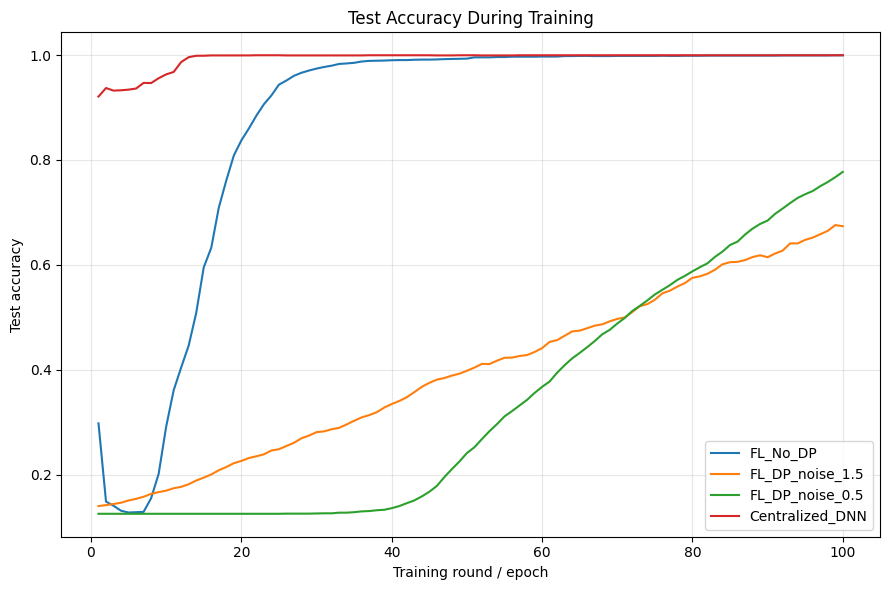

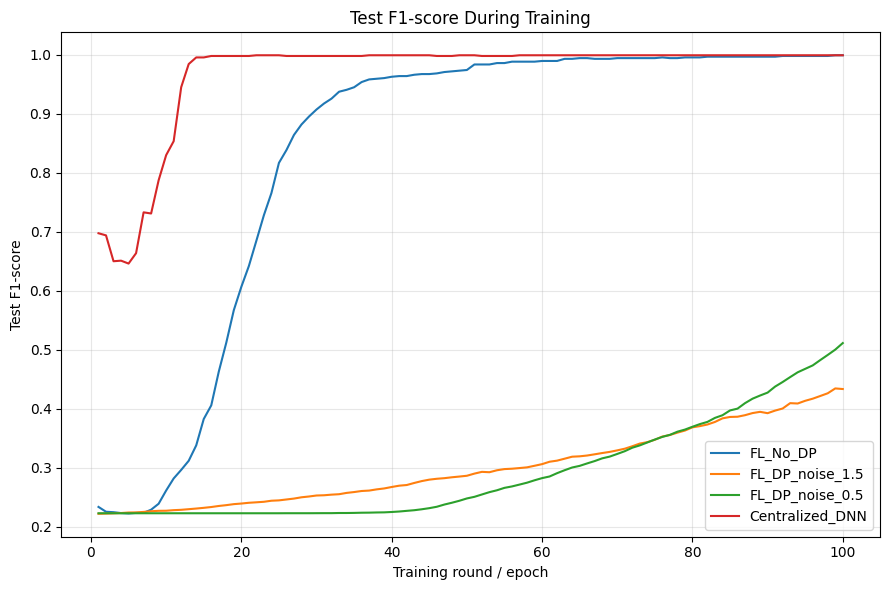

In [ ]:
# ============================================================
# 18. PLOT TRAINING CURVES
# ============================================================

# Accuracy curves
plt.figure(figsize=(9, 6))

for name, result in experiment_results.items():
    history = result["history"]

    if "round" in history.columns:
        x = history["round"]
    else:
        x = history["epoch"]

    plt.plot(
        x,
        history["test_accuracy"],
        label=name,
    )

plt.xlabel("Training round / epoch")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy During Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "test_accuracy_curves.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# F1 curves
plt.figure(figsize=(9, 6))

for name, result in experiment_results.items():
    history = result["history"]

    if "round" in history.columns:
        x = history["round"]
    else:
        x = history["epoch"]

    plt.plot(
        x,
        history["test_f1"],
        label=name,
    )

plt.xlabel("Training round / epoch")
plt.ylabel("Test F1-score")
plt.title("Test F1-score During Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "test_f1_curves.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


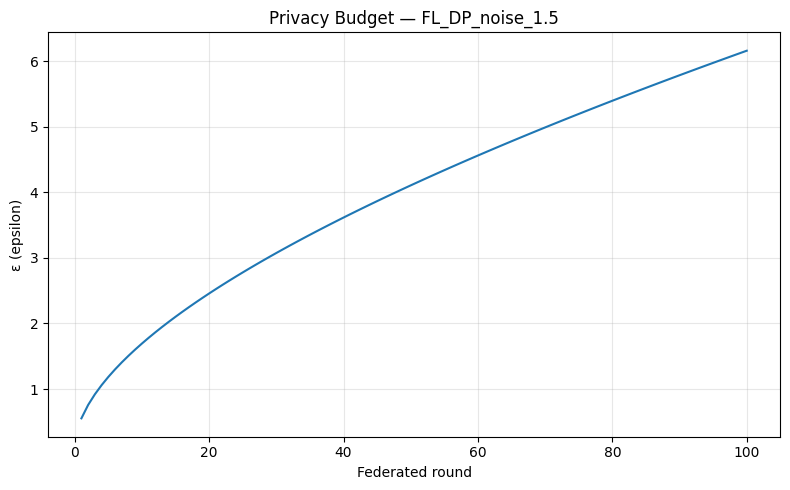

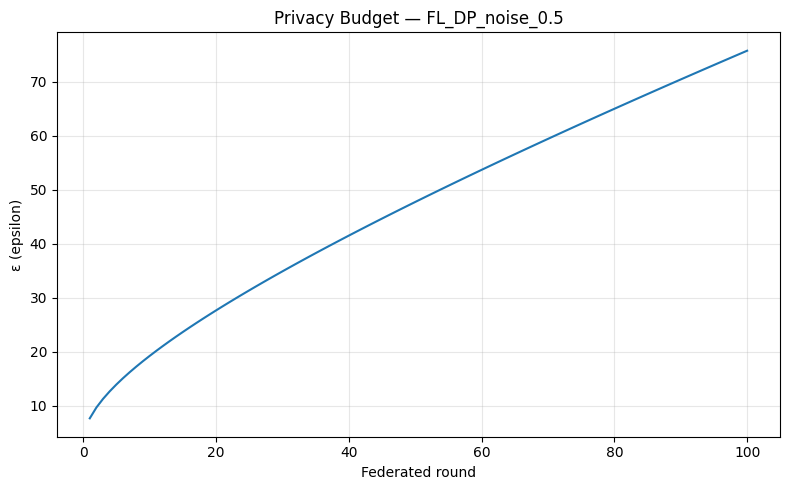

In [ ]:
import re

# ============================================================
# 19. DP PRIVACY BUDGET CURVES
# ============================================================

for name, result in experiment_results.items():
    history = result["history"]

    if "epsilon" not in history.columns:
        continue

    plt.figure(figsize=(8, 5))
    plt.plot(
        history["round"],
        history["epsilon"],
    )

    plt.xlabel("Federated round")
    plt.ylabel("ε (epsilon)")
    plt.title(f"Privacy Budget — {name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", name)

    plt.savefig(
        RESULTS_DIR / f"{safe_name}_epsilon.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

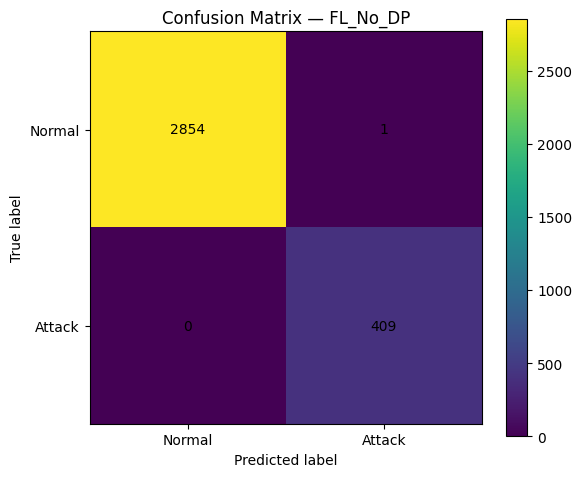

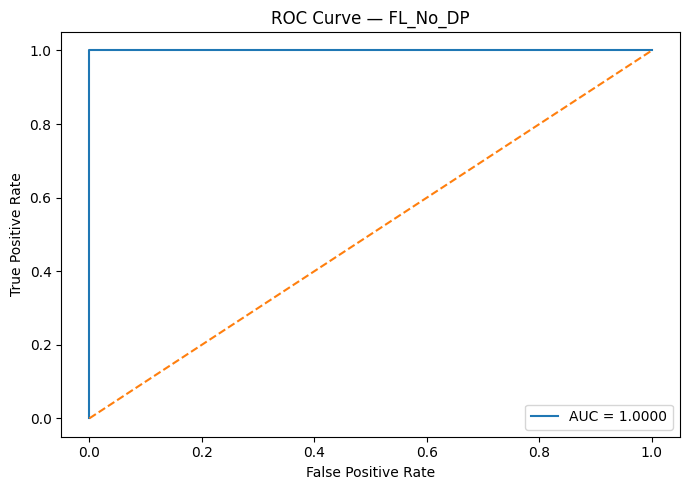

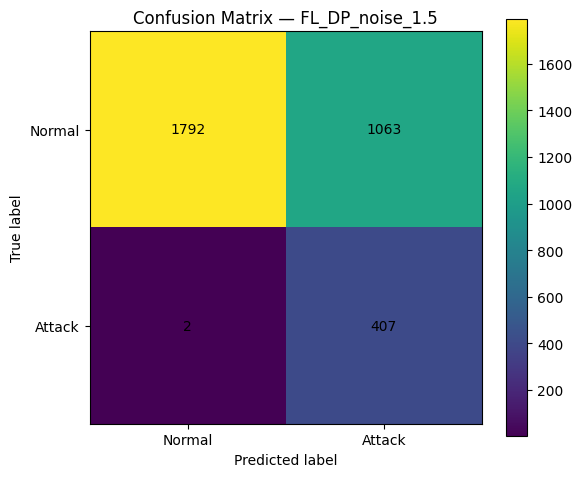

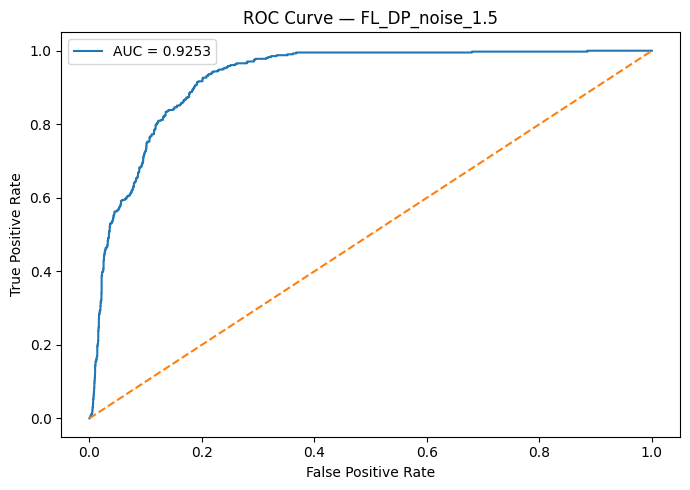

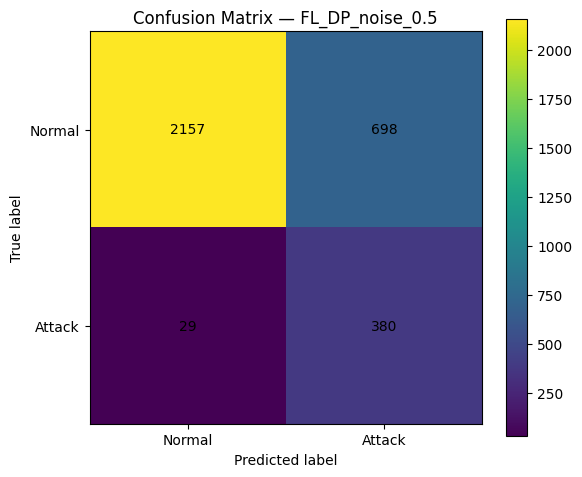

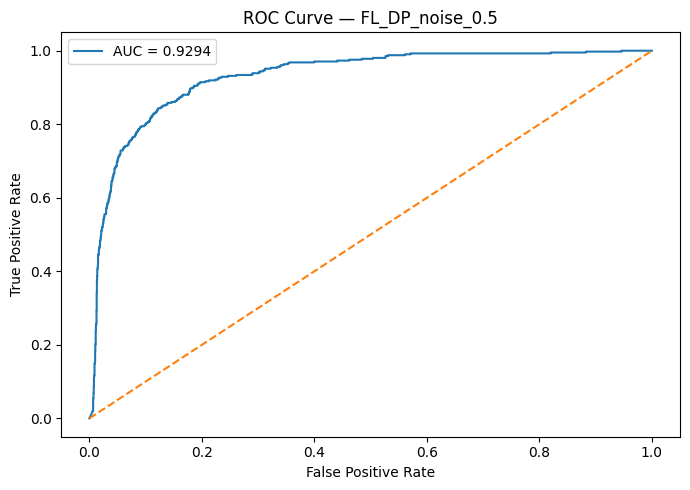

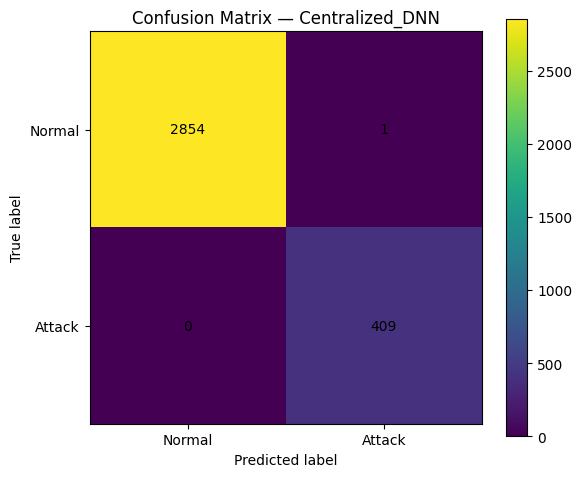

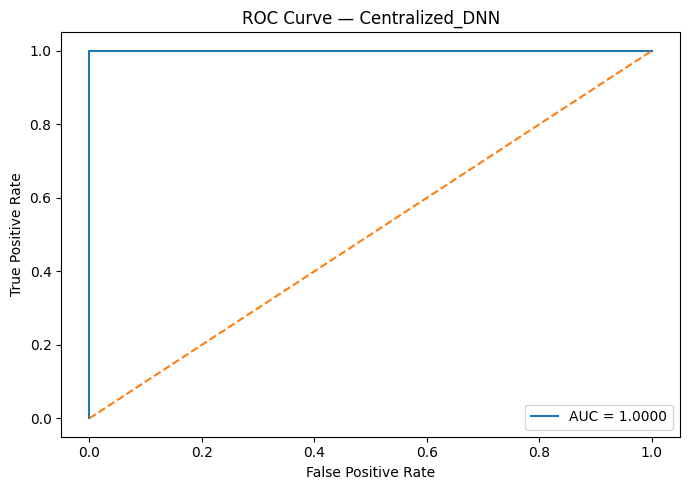

In [ ]:
# ============================================================
# 20. CONFUSION MATRICES AND ROC CURVES
# ============================================================

for name, result in experiment_results.items():

    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", name)

    plot_confusion(
        result["labels"],
        result["predictions"],
        title=f"Confusion Matrix — {name}",
        save_path=RESULTS_DIR / f"{safe_name}_confusion_matrix.png",
    )

    plot_roc(
        result["labels"],
        result["probabilities"],
        title=f"ROC Curve — {name}",
        save_path=RESULTS_DIR / f"{safe_name}_roc_curve.png",
    )


In [ ]:
# ============================================================
# 21. SAVE MODEL CHECKPOINTS AND EXPERIMENT CONFIGURATION
# ============================================================

for name, result in experiment_results.items():
    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", name)

    checkpoint = {
        "model_state_dict": result["model"].state_dict(),
        "input_dim": INPUT_DIM,
        "feature_columns": FEATURE_COLUMNS,
        "seed": SEED,
        "num_clients": NUM_CLIENTS,
        "batch_size": BATCH_SIZE,
        "federated_rounds": FEDERATED_ROUNDS,
        "local_epochs": LOCAL_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "max_grad_norm": MAX_GRAD_NORM,
        "delta": DELTA,
        "experiment": name,
        "metrics": result["metrics"],
    }

    torch.save(
        checkpoint,
        RESULTS_DIR / f"{safe_name}_model.pt",
    )

config = {
    "seed": SEED,
    "device": str(DEVICE),
    "num_clients": NUM_CLIENTS,
    "batch_size": BATCH_SIZE,
    "federated_rounds": FEDERATED_ROUNDS,
    "local_epochs": LOCAL_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "max_grad_norm": MAX_GRAD_NORM,
    "delta": DELTA,
    "dp_noise_levels": DP_NOISE_LEVELS,
    "input_dim": INPUT_DIM,
    "feature_columns": FEATURE_COLUMNS,
    "dataset": str(CSV_FILE),
}

with open(RESULTS_DIR / "experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

pd.DataFrame({
    "feature_index": range(1, INPUT_DIM + 1),
    "feature": FEATURE_COLUMNS,
}).to_csv(
    RESULTS_DIR / "feature_list.csv",
    index=False,
)

print("Saved all checkpoints and configuration to:")
print(RESULTS_DIR)


Saved all checkpoints and configuration to:
/content/drive/MyDrive/SECIoHT-FL-based-IDS-main/SECIoHT-FL-based-IDS-main/colab_results


# Final interpretation

The main comparison is:

| Experiment | Purpose |
|---|---|
| **Centralized DNN** | Upper-bound/reference where all training data are centralized |
| **FL without DP** | Measures the cost of decentralization alone |
| **FL + DP, noise=0.5** | Privacy-preserving FL with lower DP noise |
| **FL + DP, noise=1.5** | Stronger DP noise and typically greater privacy protection |

For the thesis/research report, report at least:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix
- Training time
- ε (epsilon) and δ (delta) for DP experiments

### Important methodological note

This notebook is a **standalone reconstruction using the original WUSTL-EHMS-2020.csv**. It does not claim to reproduce the authors' unavailable `clean_wustl1111.csv` exactly. The supplied repository hard-codes a 26-feature input in parts of the old notebook, but the exact feature-reduction procedure is not documented in the files provided. The notebook therefore uses the actual feature dimensionality produced by the documented preprocessing instead of arbitrarily forcing 26 features.

Also, the original notebook labels a fully-connected `Linear` network as "CNN". That architecture is not a true convolutional neural network. The standalone notebook therefore reports it correctly as a **DNN/MLP** rather than mislabeling it as CNN.
